<a href="https://colab.research.google.com/github/mashrafi356/task1_Md_Mashrafi_Islam_s4058843/blob/main/task1_Md_Mashrafi_Islam_s4058843.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Exploration


In [2]:
import pandas as pd
import numpy as np
import re

# DATASETS


tsf_file = "australian_electricity_demand_dataset.tsf"
csv_file = "electricityconsumptionbenchmarkssurveydataaergovhack.csv"


# DATASET 1: AUSTRALIAN ELECTRICITY DEMAND (.tsf)


def load_tsf_dataset(filename):

    records = []

    with open(filename, "r") as file:
        in_data = False

        for line in file:
            line = line.strip()

            # Skipping empty lines
            if not line:
                continue

            # reading data after @data
            if line.lower() == "@data":
                in_data = True
                continue

            # Ignore metadata before @data
            if not in_data:
                continue

            # Each line has:
            # series_name:state:start_timestamp:values
            parts = line.split(":", 3)

            if len(parts) != 4:
                continue

            series_name = parts[0]
            state = parts[1]
            start_timestamp = parts[2]
            values_string = parts[3]

            # Converting comma-separated demand values into numbers
            values = values_string.split(",")

            for index, value in enumerate(values):

                try:
                    demand = float(value)
                except ValueError:
                    continue

                records.append({
                    "series_name": series_name,
                    "state": state,
                    "start_timestamp": start_timestamp,
                    "interval": index,
                    "demand": demand
                })

    return pd.DataFrame(records)


df1 = load_tsf_dataset(tsf_file)


# DATASET 2: ELECTRICITY CONSUMPTION BENCHMARKS (.csv)


df2 = pd.read_csv(csv_file)



# DATASET EXPLORE


print("=" * 70)
print("DATASET 1: AUSTRALIAN ELECTRICITY DEMAND")
print("=" * 70)

print("\nShape:")
print(df1.shape)

print("\nColumns:")
print(df1.columns.tolist())

print("\nData types:")
print(df1.dtypes)

print("\nStates:")
print(df1["state"].value_counts())

print("\nMissing values:")
print(df1.isnull().sum())

print("\nFirst 5 rows:")
print(df1.head())

print("\nDemand statistics:")
print(df1["demand"].describe())


print("\n\n")
print("=" * 70)
print("DATASET 2: ELECTRICITY CONSUMPTION BENCHMARKS")
print("=" * 70)

print("\nShape:")
print(df2.shape)

print("\nColumns:")
print(df2.columns.tolist())

print("\nData types:")
print(df2.dtypes)

print("\nMissing values:")
print(df2.isnull().sum())

print("\nFirst 5 rows:")
print(df2.head())

print("\nRespondents:")
print(df2["respondent"].nunique())

print("\nTypes:")
print(df2["TYPE"].value_counts())

print("\nDates:")
print(df2["OUTPUT_DATE"].min(), "to", df2["OUTPUT_DATE"].max())



# HALF-HOURLY COLUMNS IN DATASET 2


half_hour_columns = [
    column for column in df2.columns
    if column.startswith("E_")
]

print("\nNumber of half-hourly consumption columns:")
print(len(half_hour_columns))

print("\nHalf-hourly columns:")
print(half_hour_columns)

print("\nTotal missing values in half-hourly data:")
print(df2[half_hour_columns].isnull().sum().sum())

DATASET 1: AUSTRALIAN ELECTRICITY DEMAND

Shape:
(1155264, 5)

Columns:
['series_name', 'state', 'start_timestamp', 'interval', 'demand']

Data types:
series_name         object
state               object
start_timestamp     object
interval             int64
demand             float64
dtype: object

States:
state
QUN    232272
SA     230784
NSW    230736
VIC    230736
TAS    230736
Name: count, dtype: int64

Missing values:
series_name        0
state              0
start_timestamp    0
interval           0
demand             0
dtype: int64

First 5 rows:
  series_name state      start_timestamp  interval       demand
0          T1   NSW  2002-01-01 00-00-00         0  5714.045004
1          T1   NSW  2002-01-01 00-00-00         1  5360.189078
2          T1   NSW  2002-01-01 00-00-00         2  5014.835118
3          T1   NSW  2002-01-01 00-00-00         3  4602.755516
4          T1   NSW  2002-01-01 00-00-00         4  4285.179828

Demand statistics:
count    1.155264e+06
mean     3.50

Dataset Prepare for Machine learning


In [4]:

# PREPARING DATASETS FOR MACHINE LEARNING
# DATASET 1


# Converting the starting timestamp to datetime
df1["start_timestamp"] = pd.to_datetime(
    df1["start_timestamp"],
    format="%Y-%m-%d %H-%M-%S"
)

# Creating the actual timestamp for each half-hour observation
df1["timestamp"] = (
    df1["start_timestamp"]
    + pd.to_timedelta(df1["interval"] * 30, unit="minutes")
)

# Sorting the data correctly
df1 = df1.sort_values(
    ["state", "timestamp"]
).reset_index(drop=True)

# Creatinhg previous-demand features
df1["lag_1"] = (
    df1.groupby("state")["demand"]
    .shift(1)
)

df1["lag_2"] = (
    df1.groupby("state")["demand"]
    .shift(2)
)

df1["lag_48"] = (
    df1.groupby("state")["demand"]
    .shift(48)
)

df1["lag_336"] = (
    df1.groupby("state")["demand"]
    .shift(336)
)

# Time-based features
df1["hour"] = df1["timestamp"].dt.hour
df1["day_of_week"] = df1["timestamp"].dt.dayofweek
df1["month"] = df1["timestamp"].dt.month

# Removing rows where lag values cannot be calculated
df1 = df1.dropna().reset_index(drop=True)

# Checking the result
print("Dataset 1 shape after preparation:")
print(df1.shape)

print("\nFirst 5 rows:")
print(
    df1[
        [
            "state",
            "timestamp",
            "demand",
            "lag_1",
            "lag_2",
            "lag_48",
            "lag_336",
            "hour",
            "day_of_week",
            "month"
        ]
    ].head()
)

Dataset 1 shape after preparation:
(1153584, 13)

First 5 rows:
  state           timestamp       demand        lag_1        lag_2  \
0   NSW 2002-01-08 00:00:00  5524.671836  5765.609956  6031.759626   
1   NSW 2002-01-08 00:30:00  5230.179820  5524.671836  5765.609956   
2   NSW 2002-01-08 01:00:00  4891.105618  5230.179820  5524.671836   
3   NSW 2002-01-08 01:30:00  4570.705878  4891.105618  5230.179820   
4   NSW 2002-01-08 02:00:00  4351.442234  4570.705878  4891.105618   

        lag_48      lag_336  hour  day_of_week  month  
0  5080.875022  5714.045004     0            1      1  
1  4869.641090  5360.189078     0            1      1  
2  4598.338868  5014.835118     1            1      1  
3  4394.420618  4602.755516     1            1      1  
4  4257.605676  4285.179828     2            1      1  


In [3]:
# DATASET 2

# Converting date column to datetime
df2["OUTPUT_DATE"] = pd.to_datetime(
    df2["OUTPUT_DATE"],
    dayfirst=True
)


half_hour_columns = [
    column for column in df2.columns
    if column.startswith("E_")
]

print("Number of half-hourly columns:", len(half_hour_columns))


# RESHAPING FROM WIDE TO LONG FORMAT

df2_long = df2.melt(
    id_vars=[
        "respondent",
        "OUTPUT_DATE",
        "TYPE"
    ],
    value_vars=half_hour_columns,
    var_name="time",
    value_name="consumption_wh"
)

# Sorting observations chronologically for each household/type
df2_long = df2_long.sort_values(
    ["respondent", "TYPE", "OUTPUT_DATE", "time"]
).reset_index(drop=True)


# EXTRACTING TIME INFORMATION

df2_long["time_clean"] = (
    df2_long["time"]
    .str.replace("E_", "", regex=False)
    .str.replace("_WH", "", regex=False)
)

df2_long["hour"] = (
    df2_long["time_clean"]
    .str[:2]
    .astype(int)
)

df2_long["minute"] = (
    df2_long["time_clean"]
    .str[2:]
    .astype(int)
)


# CREATE DATETIME
df2_long["timestamp"] = (
    df2_long["OUTPUT_DATE"]
    + pd.to_timedelta(df2_long["hour"], unit="hours")
    + pd.to_timedelta(df2_long["minute"], unit="minutes")
)

# CREATING PREVIOUS-CONSUMPTION FEATURES

# Previous half-hour
df2_long["lag_1"] = (
    df2_long
    .groupby(["respondent", "TYPE"])["consumption_wh"]
    .shift(1)
)

# Previous hour
df2_long["lag_2"] = (
    df2_long
    .groupby(["respondent", "TYPE"])["consumption_wh"]
    .shift(2)
)

# Previous day
df2_long["lag_48"] = (
    df2_long
    .groupby(["respondent", "TYPE"])["consumption_wh"]
    .shift(48)
)

# ADDING DAY INFORMATION

df2_long["day_of_week"] = (
    df2_long["timestamp"].dt.dayofweek
)

df2_long["month"] = (
    df2_long["timestamp"].dt.month
)




df2_long = df2_long.dropna().reset_index(drop=True)
# CHECK RESULT

print("\nDataset 2 shape after preparation:")
print(df2_long.shape)

print("\nColumns:")
print(df2_long.columns.tolist())

print("\nFirst 10 rows:")
print(
    df2_long[
        [
            "respondent",
            "TYPE",
            "timestamp",
            "consumption_wh",
            "lag_1",
            "lag_2",
            "lag_48",
            "day_of_week",
            "month"
        ]
    ].head(10)
)

Number of half-hourly columns: 48

Dataset 2 shape after preparation:
(1100112, 14)

Columns:
['respondent', 'OUTPUT_DATE', 'TYPE', 'time', 'consumption_wh', 'time_clean', 'hour', 'minute', 'timestamp', 'lag_1', 'lag_2', 'lag_48', 'day_of_week', 'month']

First 10 rows:
   respondent     TYPE           timestamp  consumption_wh  lag_1  lag_2  \
0        1098  general 2012-04-02 00:00:00              34   60.0   52.0   
1        1098  general 2012-04-02 00:30:00             216   34.0   60.0   
2        1098  general 2012-04-02 01:00:00              60  216.0   34.0   
3        1098  general 2012-04-02 01:30:00              64   60.0  216.0   
4        1098  general 2012-04-02 02:00:00              16   64.0   60.0   
5        1098  general 2012-04-02 02:30:00              52   16.0   64.0   
6        1098  general 2012-04-02 03:00:00              56   52.0   16.0   
7        1098  general 2012-04-02 03:30:00              12   56.0   52.0   
8        1098  general 2012-04-02 04:00:00   

In [5]:
# DEFINE FEATURES AND TARGET
# DATASET 1: Australian Electricity Demand

features_1 = [
    "lag_1",
    "lag_2",
    "lag_48",
    "lag_336",
    "hour",
    "day_of_week",
    "month"
]

X1 = df1[features_1]
y1 = df1["demand"]

print("=" * 60)
print("DATASET 1")
print("=" * 60)

print("Features:")
print(X1.columns.tolist())

print("\nX1 shape:", X1.shape)
print("y1 shape:", y1.shape)

print("\nTarget statistics:")
print(y1.describe())

# DATASET 2: Household Electricity Consumption

features_2 = [
    "lag_1",
    "lag_2",
    "lag_48",
    "hour",
    "minute",
    "day_of_week",
    "month"
]

X2 = df2_long[features_2]
y2 = df2_long["consumption_wh"]

print("\n")
print("=" * 60)
print("DATASET 2")
print("=" * 60)

print("Features:")
print(X2.columns.tolist())

print("\nX2 shape:", X2.shape)
print("y2 shape:", y2.shape)

print("\nTarget statistics:")
print(y2.describe())

DATASET 1
Features:
['lag_1', 'lag_2', 'lag_48', 'lag_336', 'hour', 'day_of_week', 'month']

X1 shape: (1153584, 7)
y1 shape: (1153584,)

Target statistics:
count    1.153584e+06
mean     3.501034e+03
std      2.438044e+03
min     -2.339068e+02
25%      1.065327e+03
50%      3.837770e+03
75%      5.216461e+03
max      1.286580e+04
Name: demand, dtype: float64


DATASET 2
Features:
['lag_1', 'lag_2', 'lag_48', 'hour', 'minute', 'day_of_week', 'month']

X2 shape: (1100112, 7)
y2 shape: (1100112,)

Target statistics:
count    1.100112e+06
mean     2.511307e+02
std      4.921696e+02
min      0.000000e+00
25%      2.600000e+01
50%      1.100000e+02
75%      2.800000e+02
max      4.543200e+04
Name: consumption_wh, dtype: float64


In [6]:

# TRAIN / TEST SPLIT

# DATASET 1


split_1 = int(len(X1) * 0.8)

X1_train = X1.iloc[:split_1]
X1_test = X1.iloc[split_1:]

y1_train = y1.iloc[:split_1]
y1_test = y1.iloc[split_1:]


print("=" * 60)
print("DATASET 1 — TRAIN / TEST")
print("=" * 60)

print("Training samples:", len(X1_train))
print("Testing samples:", len(X1_test))

print(
    "Training target range:",
    y1_train.index.min(),
    "to",
    y1_train.index.max()
)

print(
    "Testing target range:",
    y1_test.index.min(),
    "to",
    y1_test.index.max()
)


# DATASET 2


split_2 = int(len(X2) * 0.8)

X2_train = X2.iloc[:split_2]
X2_test = X2.iloc[split_2:]

y2_train = y2.iloc[:split_2]
y2_test = y2.iloc[split_2:]


print("\n")
print("=" * 60)
print("DATASET 2 — TRAIN / TEST")
print("=" * 60)

print("Training samples:", len(X2_train))
print("Testing samples:", len(X2_test))

print(
    "Training target range:",
    y2_train.index.min(),
    "to",
    y2_train.index.max()
)

print(
    "Testing target range:",
    y2_test.index.min(),
    "to",
    y2_test.index.max()
)

DATASET 1 — TRAIN / TEST
Training samples: 922867
Testing samples: 230717
Training target range: 0 to 922866
Testing target range: 922867 to 1153583


DATASET 2 — TRAIN / TEST
Training samples: 880089
Testing samples: 220023
Training target range: 0 to 880088
Testing target range: 880089 to 1100111


In [7]:

# DECISION TREE REGRESSION
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# DATASET 1 — DECISION TREE


dt_1 = DecisionTreeRegressor(
    max_depth=10,
    random_state=42
)

dt_1.fit(X1_train, y1_train)

y1_pred_dt = dt_1.predict(X1_test)


# Evaluating Dataset 1
mae_1_dt = mean_absolute_error(y1_test, y1_pred_dt)

rmse_1_dt = np.sqrt(
    mean_squared_error(y1_test, y1_pred_dt)
)


print("=" * 60)
print("DATASET 1 — DECISION TREE")
print("=" * 60)

print("MAE:", mae_1_dt)
print("RMSE:", rmse_1_dt)


# DATASET 2 — DECISION TREE


dt_2 = DecisionTreeRegressor(
    max_depth=10,
    random_state=42
)

dt_2.fit(X2_train, y2_train)

y2_pred_dt = dt_2.predict(X2_test)


# Evaluate Dataset 2
mae_2_dt = mean_absolute_error(y2_test, y2_pred_dt)

rmse_2_dt = np.sqrt(
    mean_squared_error(y2_test, y2_pred_dt)
)


print("\n")
print("=" * 60)
print("DATASET 2 — DECISION TREE")
print("=" * 60)

print("MAE:", mae_2_dt)
print("RMSE:", rmse_2_dt)

DATASET 1 — DECISION TREE
MAE: 95.76844044757978
RMSE: 131.64298670828987


DATASET 2 — DECISION TREE
MAE: 87.4819196856189
RMSE: 226.51402921741774


In [8]:

# kNN REGRESSION

from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np


# DATASET 1 — kNN


scaler_1 = StandardScaler()

X1_train_scaled = scaler_1.fit_transform(X1_train)
X1_test_scaled = scaler_1.transform(X1_test)


knn_1 = KNeighborsRegressor(
    n_neighbors=5
)

knn_1.fit(
    X1_train_scaled,
    y1_train
)

y1_pred_knn = knn_1.predict(X1_test_scaled)


# Evaluate Dataset 1

mae_1_knn = mean_absolute_error(
    y1_test,
    y1_pred_knn
)

rmse_1_knn = np.sqrt(
    mean_squared_error(
        y1_test,
        y1_pred_knn
    )
)


print("=" * 60)
print("DATASET 1 — kNN")
print("=" * 60)

print("MAE:", mae_1_knn)
print("RMSE:", rmse_1_knn)



# DATASET 2 — kNN


scaler_2 = StandardScaler()

X2_train_scaled = scaler_2.fit_transform(X2_train)
X2_test_scaled = scaler_2.transform(X2_test)


knn_2 = KNeighborsRegressor(
    n_neighbors=5
)

knn_2.fit(
    X2_train_scaled,
    y2_train
)

y2_pred_knn = knn_2.predict(X2_test_scaled)


# EvaluatING Dataset 2

mae_2_knn = mean_absolute_error(
    y2_test,
    y2_pred_knn
)

rmse_2_knn = np.sqrt(
    mean_squared_error(
        y2_test,
        y2_pred_knn
    )
)


print("\n")
print("=" * 60)
print("DATASET 2 — kNN")
print("=" * 60)

print("MAE:", mae_2_knn)
print("RMSE:", rmse_2_knn)

DATASET 1 — kNN
MAE: 145.14004071567942
RMSE: 194.57139782926419


DATASET 2 — kNN
MAE: 90.06753384873397
RMSE: 222.35849500109174


In [9]:
# MODEL COMPARISON


results = pd.DataFrame({
    "Dataset": [
        "Australian Electricity Demand",
        "Australian Electricity Demand",
        "Household Electricity Consumption",
        "Household Electricity Consumption"
    ],
    "Model": [
        "Decision Tree",
        "kNN",
        "Decision Tree",
        "kNN"
    ],
    "MAE": [
        mae_1_dt,
        mae_1_knn,
        mae_2_dt,
        mae_2_knn
    ],
    "RMSE": [
        rmse_1_dt,
        rmse_1_knn,
        rmse_2_dt,
        rmse_2_knn
    ]
})

print(results)

                             Dataset          Model         MAE        RMSE
0      Australian Electricity Demand  Decision Tree   95.768440  131.642987
1      Australian Electricity Demand            kNN  145.140041  194.571398
2  Household Electricity Consumption  Decision Tree   87.481920  226.514029
3  Household Electricity Consumption            kNN   90.067534  222.358495


In [10]:
# DECISION TREE FEATURE IMPORTANCE


feature_importance_1 = pd.DataFrame({
    "Feature": X1.columns,
    "Importance": dt_1.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

print("=" * 60)
print("DATASET 1 — DECISION TREE FEATURE IMPORTANCE")
print("=" * 60)

print(feature_importance_1)


feature_importance_2 = pd.DataFrame({
    "Feature": X2.columns,
    "Importance": dt_2.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

print("\n")
print("=" * 60)
print("DATASET 2 — DECISION TREE FEATURE IMPORTANCE")
print("=" * 60)

print(feature_importance_2)

DATASET 1 — DECISION TREE FEATURE IMPORTANCE
       Feature  Importance
0        lag_1    0.997648
1        lag_2    0.001012
4         hour    0.000734
3      lag_336    0.000495
2       lag_48    0.000105
5  day_of_week    0.000004
6        month    0.000003


DATASET 2 — DECISION TREE FEATURE IMPORTANCE
       Feature  Importance
0        lag_1    0.888549
2       lag_48    0.057290
3         hour    0.025239
1        lag_2    0.016048
5  day_of_week    0.006264
6        month    0.006100
4       minute    0.000511


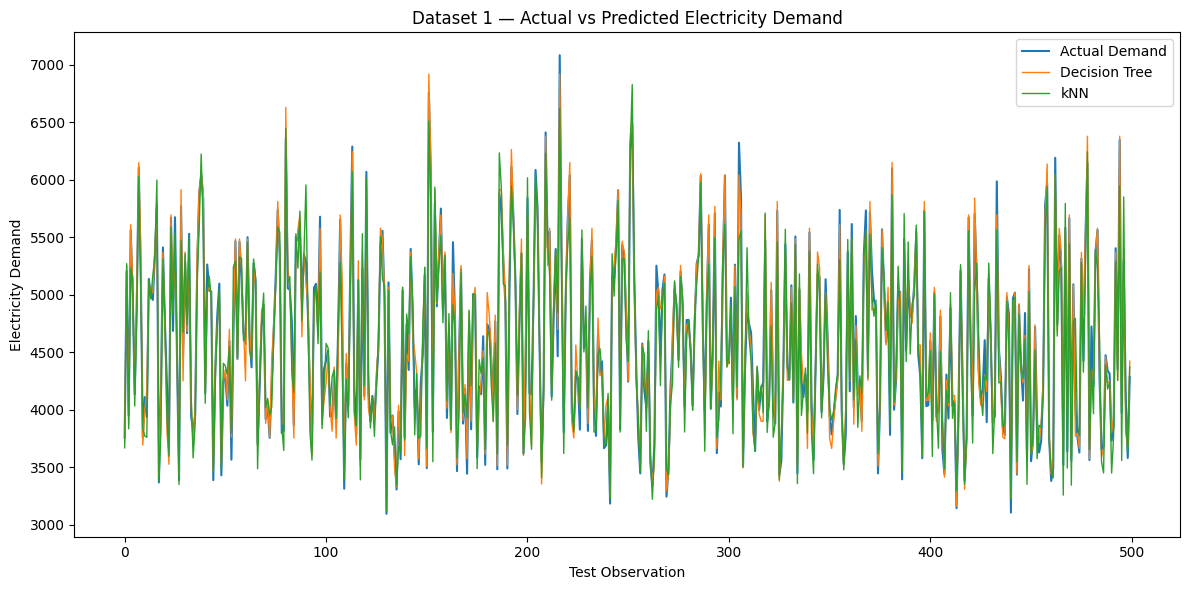

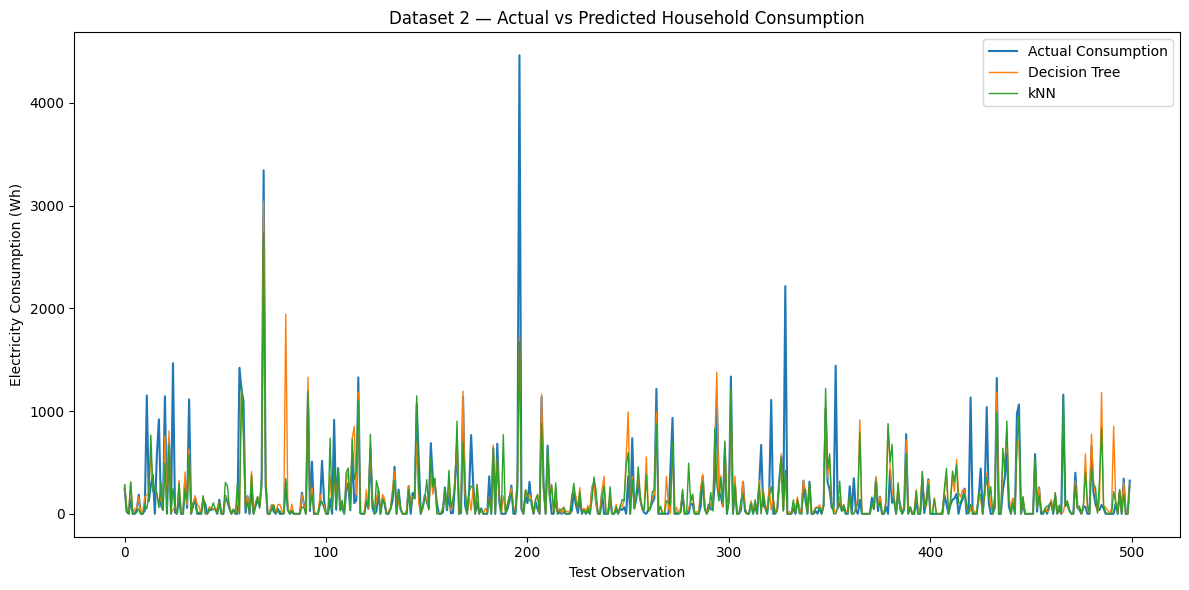

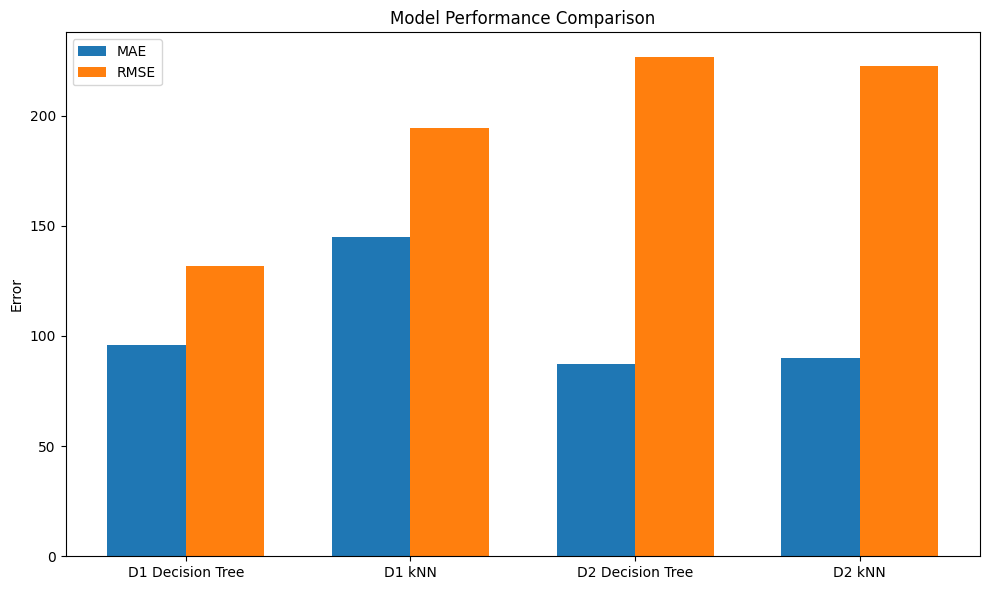

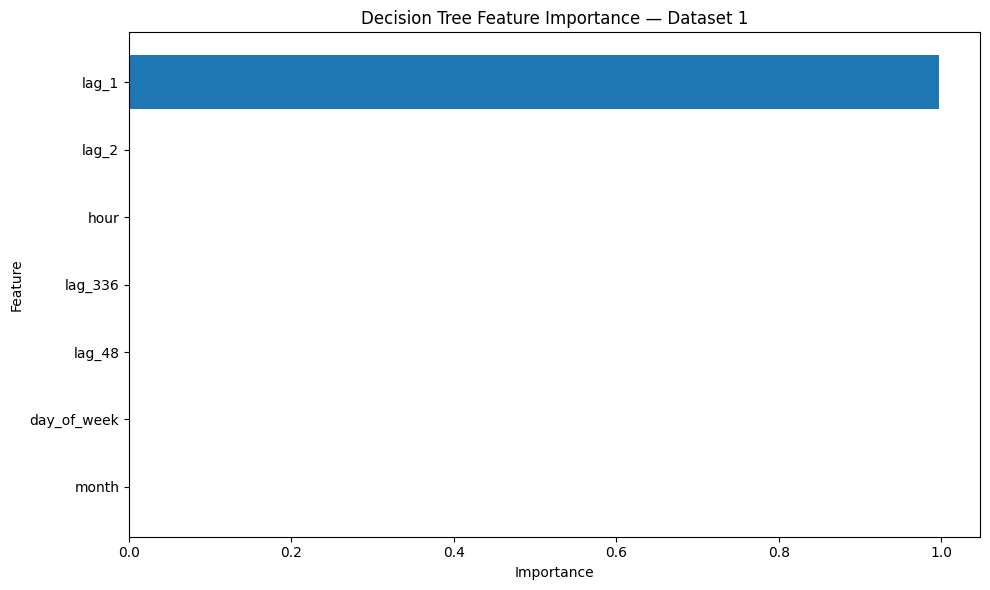

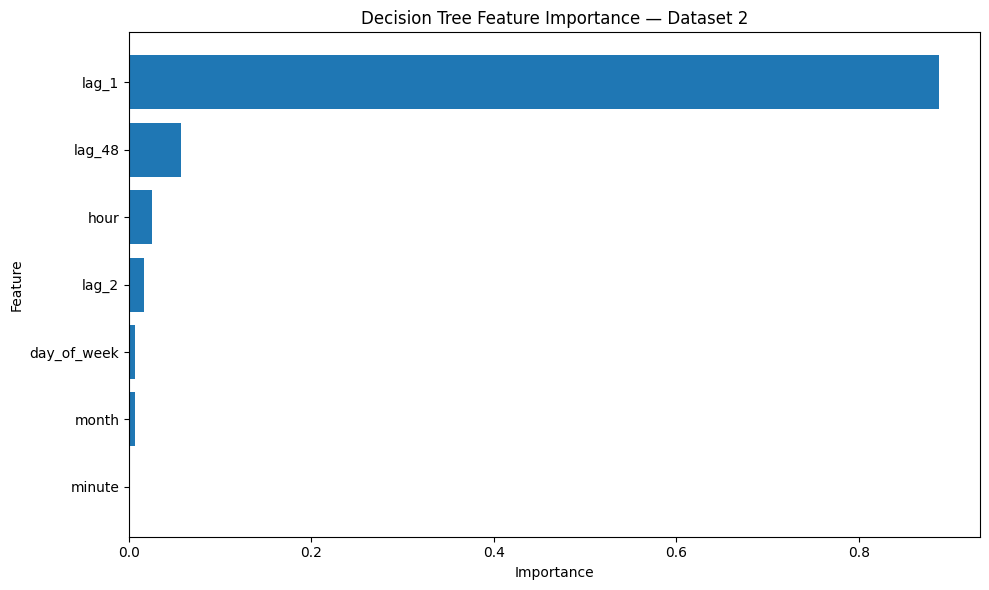

In [11]:

# VISUALISATIONS

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


#  DATASET 1 — ACTUAL VS PREDICTED

sample_size = 500


rng = np.random.default_rng(42)
sample_indices_1 = rng.choice(
    len(y1_test),
    size=sample_size,
    replace=False
)

actual_1 = np.array(y1_test)[sample_indices_1]
pred_dt_1 = y1_pred_dt[sample_indices_1]
pred_knn_1 = y1_pred_knn[sample_indices_1]

plt.figure(figsize=(12, 6))

plt.plot(
    actual_1,
    label="Actual Demand",
    linewidth=1.5
)

plt.plot(
    pred_dt_1,
    label="Decision Tree",
    linewidth=1
)

plt.plot(
    pred_knn_1,
    label="kNN",
    linewidth=1
)

plt.title("Dataset 1 — Actual vs Predicted Electricity Demand")
plt.xlabel("Test Observation")
plt.ylabel("Electricity Demand")
plt.legend()
plt.tight_layout()
plt.show()


#  DATASET 2 — ACTUAL VS PREDICTED


sample_indices_2 = rng.choice(
    len(y2_test),
    size=sample_size,
    replace=False
)

actual_2 = np.array(y2_test)[sample_indices_2]
pred_dt_2 = y2_pred_dt[sample_indices_2]
pred_knn_2 = y2_pred_knn[sample_indices_2]

plt.figure(figsize=(12, 6))

plt.plot(
    actual_2,
    label="Actual Consumption",
    linewidth=1.5
)

plt.plot(
    pred_dt_2,
    label="Decision Tree",
    linewidth=1
)

plt.plot(
    pred_knn_2,
    label="kNN",
    linewidth=1
)

plt.title("Dataset 2 — Actual vs Predicted Household Consumption")
plt.xlabel("Test Observation")
plt.ylabel("Electricity Consumption (Wh)")
plt.legend()
plt.tight_layout()
plt.show()


#  MODEL PERFORMANCE COMPARISON


results = pd.DataFrame({
    "Dataset": [
        "Dataset 1",
        "Dataset 1",
        "Dataset 2",
        "Dataset 2"
    ],
    "Model": [
        "Decision Tree",
        "kNN",
        "Decision Tree",
        "kNN"
    ],
    "MAE": [
        mae_1_dt,
        mae_1_knn,
        mae_2_dt,
        mae_2_knn
    ],
    "RMSE": [
        rmse_1_dt,
        rmse_1_knn,
        rmse_2_dt,
        rmse_2_knn
    ]
})

x = np.arange(len(results))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    results["MAE"],
    width,
    label="MAE"
)

plt.bar(
    x + width / 2,
    results["RMSE"],
    width,
    label="RMSE"
)

plt.xticks(
    x,
    [
        "D1 Decision Tree",
        "D1 kNN",
        "D2 Decision Tree",
        "D2 kNN"
    ]
)

plt.ylabel("Error")
plt.title("Model Performance Comparison")
plt.legend()
plt.tight_layout()
plt.show()



# 4. FEATURE IMPORTANCE — DATASET 1


plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance_1["Feature"],
    feature_importance_1["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Decision Tree Feature Importance — Dataset 1")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


# FEATURE IMPORTANCE — DATASET 2


plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance_2["Feature"],
    feature_importance_2["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Decision Tree Feature Importance — Dataset 2")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()